[robot_1] System Start
Obstacle detected at position: 15.0m
Emergency Stop triggered at step 10!


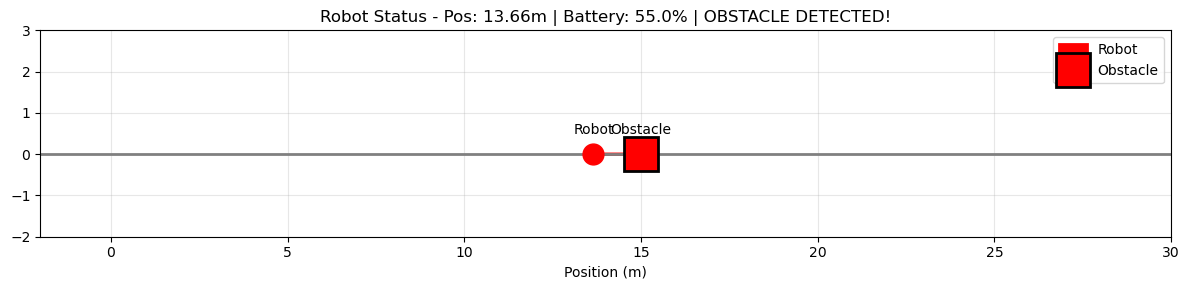

System Shutdown.


In [4]:
# 1. 导入 - 机器人的外部工具
import time
import random
import matplotlib.pyplot as plt
from IPython.display import clear_output

# 2. 变量 - 机器人的状态
robot_name = "robot_1"
battery_level = 100
position = 0
is_running = True

# 障碍物位置 (设置在 15m 处)
obstacle_pos = 15.0

# 历史轨迹记录 (用于可视化)
trajectory_x = [0]
trajectory_y = [0]
obstacle_detected = False

def move_forward(current_pos, speed):
    """让机器人向前移动一步，并模拟噪声"""
    # 模拟传感器噪声
    noise = random.uniform(-0.1, 0.1)
    real_distance = speed + noise
    new_pos = current_pos + real_distance
    return new_pos

def detect_obstacle(current_pos, obstacle_position, detection_range=2.0):
    """检测前方是否有障碍物"""
    distance_to_obstacle = obstacle_position - current_pos
    return 0 < distance_to_obstacle <= detection_range

def visualize_robot(position, obstacle_pos, obstacle_detected):
    """可视化机器人和障碍物"""
    plt.figure(figsize=(12, 3))
    
    # 绘制地面
    plt.hlines(y=0, xmin=-2, xmax=30, colors='gray', linestyles='-', linewidth=2)
    
    # 绘制机器人 (使用箭头表示方向)
    color = 'red' if obstacle_detected else 'green'
    plt.arrow(position, 0, 1, 0, head_width=0.3, head_length=0.3, fc=color, ec=color, linewidth=2, label='Robot')
    plt.plot(position, 0, 'o', color=color, markersize=15)
    plt.text(position, 0.5, 'Robot', ha='center', fontsize=10)
    
    # 绘制障碍物
    plt.plot(obstacle_pos, 0, 's', color='red', markersize=25, markeredgecolor='black', markeredgewidth=2, label='Obstacle')
    plt.text(obstacle_pos, 0.5, 'Obstacle', ha='center', fontsize=10)
    
    # 设置图表属性
    plt.xlim(-2, 30)
    plt.ylim(-2, 3)
    plt.xlabel('Position (m)')
    plt.title(f'Robot Status - Pos: {position:.2f}m | Battery: {battery_level}% | {"OBSTACLE DETECTED!" if obstacle_detected else "Moving"}')
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

print(f"[{robot_name}] System Start")
print(f"Obstacle detected at position: {obstacle_pos}m")
print("=" * 50)

step_count = 0
while is_running:
    step_count += 1
    
    # 检查电池
    if battery_level < 20:
        print("Warning: Low battery!")
        is_running = False
        break
    
    # 检测障碍物
    if detect_obstacle(position, obstacle_pos):
        obstacle_detected = True
        print(f"WARNING: Obstacle detected at {obstacle_pos}m! Current position: {position:.2f}m")
        print(f"Emergency Stop triggered at step {step_count}!")
        is_running = False
        break
    
    # 移动机器人
    position = move_forward(position, 1.5)
    battery_level -= 5.0
    
    # 记录轨迹
    trajectory_x.append(position)
    trajectory_y.append(0)
    
    # 打印状态
    status_msg = f"Status: Moving | Pos: {position:.2f}m | Battery: {battery_level:.0f}%"
    print(f"[{step_count}] {status_msg}")
    
    # 清空输出并可视化
    clear_output(wait=True)
    print(f"[{robot_name}] System Start")
    print(f"Obstacle detected at position: {obstacle_pos}m")
    print("=" * 50)
    print(f"[{step_count}] {status_msg}")
    visualize_robot(position, obstacle_pos, False)
    
    time.sleep(0.5)

# 最终状态显示
clear_output(wait=True)
print(f"[{robot_name}] System Start")
print(f"Obstacle detected at position: {obstacle_pos}m")
print("=" * 50)

if obstacle_detected:
    print(f"WARNING: Obstacle detected at {obstacle_pos}m! Current position: {position:.2f}m")
    print(f"Emergency Stop triggered at step {step_count}!")
    visualize_robot(position, obstacle_pos, True)
elif battery_level < 20:
    print("Warning: Low battery!")
    print(f"Final position: {position:.2f}m")
    visualize_robot(position, obstacle_pos, False)

print("=" * 50)
print("System Shutdown.")